In [1]:
import os, random
import numpy as np
import torch
from local_negotiator_v2 import load_negotiator_dataset, prepare_dataset, evaluate_strict_decentralized, LocalNegotiatorGNN
from superglue_negotiator_new import SuperGlueSwarmMatcher, evaluate_superglue_matcher
from super_decent_auction_new import (
    SuperDecentAuctionModel,
    train_super_decent_auction,
    evaluate_super_decent_auction,
)

SEED = 42
DATASET = './dataset/negotiator_dataset_v1.pt'
BASE_CKPT = 'strict_local_negotiator_best_v1.pt'
MATCHER_CKPT = './model/superglue_negotiator_best_new_v4.pt'
OUT = './model/super_decent_auction_best_new_v4.pt'
EPOCHS = 80
LR = 2e-4
MAX_TRAIN = 5000
MAX_VAL = 500
MAX_TEST = 500

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE} | Torch: {torch.__version__}')


Device: cuda | Torch: 2.10.0+cu128


In [2]:
matcher = SuperGlueSwarmMatcher().to(DEVICE)
if os.path.isfile(MATCHER_CKPT):
    ckpt = torch.load(MATCHER_CKPT, map_location='cpu', weights_only=False)
    matcher.load_state_dict(ckpt['model_state_dict'],strict=False)
    matcher.to(DEVICE)
    print(f'Loaded matcher checkpoint: {MATCHER_CKPT}')
else:
    print('No matcher checkpoint found. Run train_superglue_negotiator.ipynb first for the recommended path.')
    print('Continuing is allowed, but the backbone starts random and the freeze guard may keep it frozen.')

model = SuperDecentAuctionModel(matcher).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')


Loaded matcher checkpoint: ./model/superglue_negotiator_best_new_v4.pt
Parameters: 624,546


In [3]:
raw = load_negotiator_dataset(DATASET)
train_data, val_data, test_data = prepare_dataset(
    raw,
    model.formation_embedding.weight.detach().cpu(),
    seed=SEED,
    force_gt_visibility=False,
)
train_data = train_data[:MAX_TRAIN]
val_data = val_data[:MAX_VAL]
test_data = test_data[:MAX_TEST]
print(f'Train={len(train_data)} Val={len(val_data)} Test={len(test_data)}')


Train=5000 Val=500 Test=500


In [4]:
print('=== Baselines before super_decent training ===')
print('\nSuperGlue matcher alone:')
matcher_metrics = evaluate_superglue_matcher(model.matcher, test_data[:200], DEVICE)
for k, v in matcher_metrics.items(): print(f'  {k}: {v:.4f}')

print('\nSuperGlue + DecentAuction:')
auction_metrics = evaluate_super_decent_auction(model, test_data[:200], DEVICE)
for k, v in auction_metrics.items(): print(f'  {k}: {v:.4f}')

if os.path.isfile(BASE_CKPT):
    base = LocalNegotiatorGNN().to(DEVICE)
    ckpt = torch.load(BASE_CKPT, map_location='cpu', weights_only=False)
    base.load_state_dict(ckpt['model_state_dict'])
    base.to(DEVICE)
    print('\nBase gossip checkpoint:')
    gossip = evaluate_strict_decentralized(base, test_data[:200], DEVICE)
    for k, v in gossip.items(): print(f'  {k}: {v:.4f}')


=== Baselines before super_decent training ===

SuperGlue matcher alone:
  bijection_rate: 0.8000
  conflict_rate: 0.0164
  unassigned_rate: 0.0000
  cost_ratio_vs_hungarian: 0.9988
  slot_match_rate: 0.8651
  consensus_rounds: 0.0000
  mean_eps: 0.8576

SuperGlue + DecentAuction:
  bijection_rate: 1.0000
  conflict_rate: 0.0000
  unassigned_rate: 0.0000
  cost_ratio_vs_hungarian: 1.0027
  slot_match_rate: 0.8597
  consensus_rounds: 5.3650
  converged_rate: 0.9950
  messages_sent: 734.8800

Base gossip checkpoint:
  bijection_rate: 0.8300
  conflict_rate: 0.0030
  unassigned_rate: 0.0078
  cost_ratio_vs_hungarian: 1.0227
  slot_match_rate: 0.7001
  consensus_rounds: 8.5650
  converged_rate: 0.7100


In [5]:
print('=== Training SuperGlue + DecentAuction ===')
history = train_super_decent_auction(
    model,
    train_data,
    val_data,
    DEVICE,
    epochs=EPOCHS,
    lr=LR,
    force_gt_train=True,
    eval_subset=100,
    ckpt_path=OUT,
)


=== Training SuperGlue + DecentAuction ===
epoch 001 [frozen] train=0.5666 val=0.7869 bij=1.000 cost=1.0025 match=0.893 unass=0.000 rounds=4.5
epoch 002 [frozen] train=0.5564 val=0.8618 bij=1.000 cost=1.0037 match=0.880 unass=0.000 rounds=4.8
epoch 003 [frozen] train=0.5505 val=0.8246 bij=1.000 cost=1.0037 match=0.883 unass=0.000 rounds=4.6
epoch 004 [frozen] train=0.5392 val=0.9445 bij=1.000 cost=1.0032 match=0.864 unass=0.000 rounds=4.5
epoch 005 [frozen] train=0.5233 val=0.8284 bij=1.000 cost=1.0029 match=0.899 unass=0.000 rounds=4.5
epoch 006 [frozen] train=0.5183 val=0.8228 bij=1.000 cost=1.0035 match=0.897 unass=0.000 rounds=4.5
epoch 007 [frozen] train=0.5040 val=0.8096 bij=1.000 cost=1.0033 match=0.899 unass=0.000 rounds=4.6
epoch 008 [frozen] train=0.4924 val=0.8223 bij=1.000 cost=1.0035 match=0.899 unass=0.000 rounds=4.6
epoch 009 [frozen] train=0.4748 val=0.8369 bij=1.000 cost=1.0032 match=0.899 unass=0.000 rounds=4.5
epoch 010 [frozen] train=0.4935 val=0.8359 bij=1.000 cost

In [6]:
# Run this right now
from local_negotiator_v2 import SLOT_VISIBILITY_RADIUS, COMM_RADIUS
print(f'SLOT_VISIBILITY_RADIUS: {SLOT_VISIBILITY_RADIUS}')
print(f'COMM_RADIUS: {COMM_RADIUS}')
print(f'ARENA_SIZE: 10.0')
print(f'Max possible drone-slot distance: {10*1.414:.2f}')

SLOT_VISIBILITY_RADIUS: 8.0
COMM_RADIUS: 6.0
ARENA_SIZE: 10.0
Max possible drone-slot distance: 14.14


In [7]:
print('=== Final evaluation ===')
matcher_final = evaluate_superglue_matcher(model.matcher, test_data, DEVICE)
auction_final = evaluate_super_decent_auction(model, test_data, DEVICE)

print('\nMatcher alone:')
for k, v in matcher_final.items(): print(f'  {k}: {v:.4f}')
print('\nSuperGlue + DecentAuction:')
for k, v in auction_final.items(): print(f'  {k}: {v:.4f}')

torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'epochs': EPOCHS,
        'lr': LR,
        'matcher_checkpoint': MATCHER_CKPT if os.path.isfile(MATCHER_CKPT) else None,
        'inference': 'SuperGlue value initializer + fully local-state DecentAuction',
    },
    'history': history,
    'metrics': {
        'matcher': matcher_final,
        'super_decent_auction': auction_final,
    },
}, OUT)
print(f'Saved -> {OUT}')


=== Final evaluation ===



Matcher alone:
  bijection_rate: 0.8220
  conflict_rate: 0.0139
  unassigned_rate: 0.0000
  cost_ratio_vs_hungarian: 0.9996
  slot_match_rate: 0.8648
  consensus_rounds: 0.0000
  mean_eps: 0.8836

SuperGlue + DecentAuction:
  bijection_rate: 0.9960
  conflict_rate: 0.0000
  unassigned_rate: 0.0003
  cost_ratio_vs_hungarian: 1.0033
  slot_match_rate: 0.8648
  consensus_rounds: 5.0120
  converged_rate: 0.9960
  messages_sent: 683.1360
Saved -> ./model/super_decent_auction_best_new_v4.pt


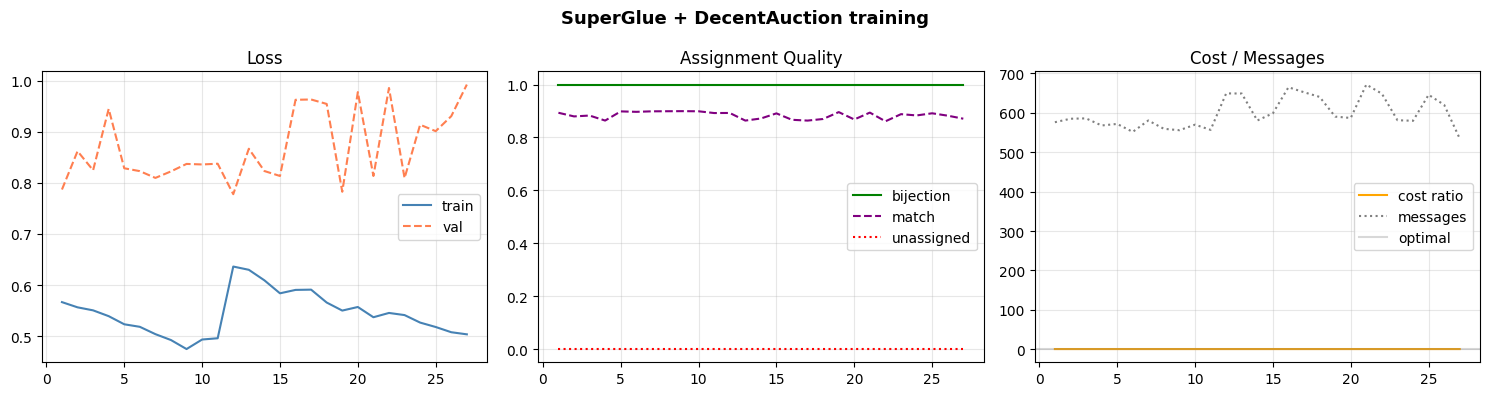

Saved super_decent_auction_training_curves.png


In [8]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('SuperGlue + DecentAuction training', fontsize=13, fontweight='bold')
ep = range(1, len(history['train_loss']) + 1)
axes[0].plot(ep, history['train_loss'], label='train', color='steelblue')
axes[0].plot(ep, history['val_loss'], label='val', color='coral', linestyle='--')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, history['val_bijection_rate'], label='bijection', color='green')
axes[1].plot(ep, history['val_slot_match_rate'], label='match', color='purple', linestyle='--')
axes[1].plot(ep, history['val_unassigned_rate'], label='unassigned', color='red', linestyle=':')
axes[1].set_title('Assignment Quality'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(ep, history['val_cost_ratio_vs_hungarian'], label='cost ratio', color='orange')
axes[2].plot(ep, history['val_messages_sent'], label='messages', color='gray', linestyle=':')
axes[2].axhline(1.0, color='gray', linestyle='-', alpha=0.3, label='optimal')
axes[2].set_title('Cost / Messages'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('super_decent_auction_training_curves.png', dpi=120)
plt.show()
print('Saved super_decent_auction_training_curves.png')
